[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab1-NetworkSci-PSN/notebooks/02b-patient_similarity_network_iris_extended.ipynb)


Last updated: 2025-12-21, A. Lundervold

Lab 1: use the `bmed365-2026` conda environment


# Patient Similarity Network with Extended IRIS Data

## From continuous measurements to mixed data – towards more realistic clinical scenarios

---

### 🎯 Learning Objectives

After this notebook you should be able to:

1. **Understand the challenge of mixed data** – the combination of continuous, categorical, and ordinal variables
2. **Generate realistic synthetic datasets** based on known distributions
3. **Compute Gower distance** and other similarity measures for mixed data
4. **Compare results** from different similarity measures
5. **Reflect on variable selection and weighting** in clinical PSN applications

---

### 🌸 Why extend the IRIS dataset?

In the previous notebook (`02-patient_similarity_network_iris.ipynb`) we used the original IRIS dataset with only **continuous variables** (four flower measurements). 

But in real clinical data we almost always have a **mix of variable types**:

| Variable type | Examples (clinical) | Examples (IRIS-extended) |
|--------------|---------------------|--------------------------|
| **Continuous** | Blood pressure, age, lab values | Petal length, width, etc. |
| **Categorical (nominal)** | Sex, blood type, diagnosis | Habitat, region, leaf shape |
| **Ordinal** | Pain level (1-10), disease stage | Health status, growth stage |
| **Binary** | Smoker (yes/no), diabetes (yes/no) | Blooming (yes/no), damaged (yes/no) |

**The challenge:** Euclidean distance only works for continuous data. What do we do when we have mixed data?


<details>
<summary>🌿 <b>Deep Dive: The Biology Behind IRIS Species</b> (click to expand)</summary>

### The Three IRIS Species in the Dataset

**Iris setosa** (Dwarf Iris)
- **Habitat:** Wetlands, bogs, arctic regions
- **Geographic distribution:** Alaska, Canada, Siberia, Northern Europe
- **Characteristics:** Low growth (15-30 cm), tolerates frost well
- **Flower color:** Often blue-purple with white and yellow markings

**Iris versicolor** (Blue Flag)
- **Habitat:** Moist meadows, wetlands, riverbanks
- **Geographic distribution:** Eastern North America
- **Characteristics:** Medium height (30-60 cm), variable in appearance
- **Flower color:** Blue-violet, can vary significantly

**Iris virginica** (Southern Blue Flag)
- **Habitat:** Wetlands, swamps, coastal areas
- **Geographic distribution:** Southeastern USA
- **Characteristics:** Tall growth (60-90 cm), larger flowers
- **Flower color:** Deep blue-purple

### Do IRIS flowers have sex?

**No** – Iris flowers are **hermaphrodites** (bisexual). Each flower has both:
- **Stamens** (male organs) that produce pollen
- **Pistil** (female organs) that receive pollen

This is common for many flowering plants and is called **perfect flowers** in botany.

### So why do we simulate "categorical variables"?

Although the flowers don't have sex, they have many other categorical characteristics:
- Habitat type (wetland, meadow, forest)
- Geographic region
- Leaf shape and color
- Health status
- Growth stage

In this notebook we simulate these variables to learn techniques that are directly transferable to patient data!

</details>


---
## Part 1: Preparation and Data Generation


### Step 1: Load necessary libraries


In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Numerical computations and data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Network analysis
import networkx as nx

# Original data
from sklearn.datasets import load_iris

# For Gower distance
from scipy.spatial.distance import pdist, squareform

# For categorical handling
from sklearn.preprocessing import LabelEncoder

# Helper functions
from IPython.display import display, Markdown, HTML
from typing import Dict, List, Tuple, Optional

# Set aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✓ All libraries loaded!")


✓ All libraries loaded!


### Step 2: Generate synthetic extended IRIS dataset

We create a dataset with **n=600** flowers (200 per species) that includes:
- **4 continuous variables** (based on original data)
- **3 categorical variables** (habitat, region, leaf shape)
- **2 ordinal variables** (health status, growth stage)
- **2 binary variables** (blooming, damaged)


<details>
<summary>🌿 <b>Deep Dive: Motivation for the New Variables</b> (click to expand)</summary>

### The Three IRIS Species

<img src="../assets/iris_species.png" width="700">

*The three species in the IRIS dataset: Iris setosa, Iris versicolor, and Iris virginica. Note the characteristic differences in petal and sepal. Source: [DAT158 course, HVL](https://github.com/HVL-ML/DAT158)*

---

### Why these specific variables?

The four original IRIS variables (sepal/petal length and width) are well-established measurements from [Fisher's classic 1936 dataset](https://onlinelibrary.wiley.com/doi/10.1111/j.1469-1809.1936.tb02137.x). But in a realistic botanical field study, researchers would typically record many more characteristics. Here is the ecological rationale for each new variable:

---

### 📍 Categorical Variables

**Habitat (wetland, meadow, forest)**

The three IRIS species have different habitat preferences reflecting their evolutionary adaptations:

| Species | Preferred habitat | Ecological explanation |
|-----|---------------------|----------------------|
| *I. setosa* | **Wetland** (70%) | Arctic/subarctic species adapted to bog landscapes and moist tundra areas |
| *I. versicolor* | **Meadow/wetland** (equal) | Generalist that thrives in transition zones between wet and dry ground |
| *I. virginica* | **Wetland** (60%) | Swamp plant that grows along riverbanks and coastal marshes in southern USA |

**Region (north, central, south)**

Geographic distribution follows the species' natural range:

| Species | Dominant region | Natural distribution |
|-----|-------------------|---------------------|
| *I. setosa* | **North** (80%) | Circumpolar: Alaska, Canada, Siberia, Northern Scandinavia |
| *I. versicolor* | **Central** (60%) | Temperate North America: Great Lakes region to New England |
| *I. virginica* | **South** (60%) | Subtropical/temperate: Virginia to Florida, Gulf Coast |

**Leaf shape (narrow, medium, wide)**

Leaf morphology varies with climate adaptation:

- **Narrow leaves** → Reduces water loss, common in cold/dry conditions (*I. setosa*)
- **Wide leaves** → Maximizes photosynthesis in warm, humid areas (*I. virginica*)
- **Medium** → Balanced adaptation in temperate zones (*I. versicolor*)

---

### 📊 Ordinal Variables

**Health status (1-5 scale)**

This variable simulates a field botanist's assessment of the plant's general condition:

| Score | Description | Typical signs |
|-------|-------------|--------------|
| 1 | Very poor | Extensive yellowing, wilting, visible disease |
| 2 | Poor | Partial yellowing, reduced growth |
| 3 | Medium | Some weak signs, but generally acceptable |
| 4 | Good | Healthy growth, green leaves, normal size |
| 5 | Excellent | Optimal condition, vigorous flowering |

*I. setosa* has the highest average health (4.0) because it is evolutionarily adapted to harsh conditions and thus more robust. *I. virginica* has the lowest (3.2) because it grows in wetlands with more disease pressure (fungi, rot).

**Growth stage (young → mature → old)**

Iris plants are perennials and undergo distinct life phases:

| Stage | Age (typical) | Characteristics |
|---------|----------------|------------|
| Young | 1-2 years | Small rhizomes, few leaves, rarely flowering |
| Mature | 3-7 years | Optimal size, vigorous flowering |
| Old | 8+ years | Large clumps, may have reduced vitality |

---

### ✅ Binary Variables

**Blooming (yes/no)**

Not all individuals bloom every year – this depends on:
- **Age**: Young plants bloom less frequently
- **Resources**: Nutrient-poor soil → fewer flowers
- **Season**: Collection timing affects (simulated: early summer)

*I. setosa* has the highest blooming rate (60%) because the short growing season in the north favors rapid reproduction.

**Damaged (yes/no)**

Damage can be caused by:
- **Herbivory**: Deer, rabbits, insects
- **Disease**: Fungal outbreaks (especially in moist habitats)
- **Mechanical**: Wind, trampling, flooding

*I. setosa* has the lowest damage rate (10%) due to toxic alkaloids and isolated habitats. *I. virginica* has the highest (25%) because wetland habitat provides higher disease pressure.

---

### 🏥 Clinical Analogy

These variables have direct parallels to patient data:

| IRIS variable | Clinical analog | Variable type |
|---------------|----------------|--------------|
| sepal_length etc. | Blood tests (HbA1c, cholesterol) | Continuous |
| habitat | Residence (urban/rural/coastal) | Categorical |
| region | Geographic health region | Categorical |
| leaf shape | Body type/constitution | Categorical |
| health | Physicians' clinical assessment | Ordinal |
| growth stage | Age group (child/adult/elderly) | Ordinal |
| blooming | Pregnant (yes/no) | Binary |
| damaged | Previous injury/disease (yes/no) | Binary |

---

### 📚 References and Further Reading

**Original dataset:**
- Fisher, R.A. (1936). ["The use of multiple measurements in taxonomic problems"](https://onlinelibrary.wiley.com/doi/10.1111/j.1469-1809.1936.tb02137.x). *Annals of Eugenics*, 7(2), 179-188.

**Botanical resources on IRIS species:**
- [USDA Plants Database: *Iris setosa*](https://plants.usda.gov/home/plantProfile?symbol=IRSE)
- [USDA Plants Database: *Iris versicolor*](https://plants.usda.gov/home/plantProfile?symbol=IRVE2)
- [USDA Plants Database: *Iris virginica*](https://plants.usda.gov/home/plantProfile?symbol=IRVI)
- [Flora of North America: Iris](http://www.efloras.org/florataxon.aspx?flora_id=1&taxon_id=116630)

**On habitats and ecology:**
- [Missouri Botanical Garden: Iris versicolor](https://www.missouribotanicalgarden.org/PlantFinder/PlantFinderDetails.aspx?taxonid=279555)
- [Lady Bird Johnson Wildflower Center: Native Iris species](https://www.wildflower.org/plants/search.php?search_field=iris&newsearch=true)

</details>


#### 🔬 Algorithm for Synthetic Data Generation

To create a realistic extended dataset we use a **parametric simulation method** that preserves the statistical properties of the original IRIS dataset, while adding new variables with biologically plausible distributions.

**Method:**

1. **Continuous variables** – Generated from normal distributions $X \sim \mathcal{N}(\mu, \sigma)$ where $\mu$ and $\sigma$ are estimated from original data for each species:
   - We use the actual means and standard deviations from Fisher's 150 flowers
   - This ensures that the synthetic data has the same statistical signature as real data

2. **Categorical variables** – Generated from multinomial distributions with species-specific probabilities:
   - Probabilities are based on biological knowledge of species ecology
   - Example: *I. setosa* has 70% probability for wetland, 20% meadow, 10% forest

3. **Ordinal variables** – Combination of normal distribution and discretization:
   - Health status: $\text{health} = \text{round}(\text{clip}(\mathcal{N}(\mu_h, 0.8), 1, 5))$
   - Growth stage: Multinomial with species-specific probabilities

4. **Binary variables** – Generated from Bernoulli distributions:
   - $\text{blooming} \sim \text{Bernoulli}(p_b)$ where $p_b$ varies per species
   - $\text{damaged} \sim \text{Bernoulli}(p_d)$ where $p_d$ reflects vulnerability

**Why this approach?**

| Advantage | Explanation |
|--------|------------|
| **Reproducibility** | `random_state` gives identical results every time |
| **Scalability** | We can generate any number of samples (n=600 vs. original n=150) |
| **Realistic correlations** | Species-specific parameters preserve natural relationships |
| **Pedagogical value** | Students can experiment with parameters and see the effect |

**Parameters in the code below:**

```
species_params = {
    'setosa': {
        'sepal_length': (μ=5.0, σ=0.35),  # From original data
        'habitat_probs': [0.7, 0.2, 0.1],  # Biologically motivated
        'health_mean': 4.0,                # Robust species → high health
        ...
    },
    ...
}
```


In [2]:
def generate_extended_iris_data(n_per_species: int = 200, random_state: int = 42) -> pd.DataFrame:
    """
    Generates an extended IRIS dataset with mixed variables.
    
    Parameters:
    -----------
    n_per_species : int
        Number of flowers per species (total becomes n = 3 * n_per_species)
    random_state : int
        Seed for reproducibility
    
    Returns:
    --------
    pd.DataFrame
        Extended dataset with continuous, categorical, ordinal, and binary variables
    """
    np.random.seed(random_state)
    
    # Load original data to get realistic parameters
    iris = load_iris()
    
    # Parameters for each species (mean and std from original data)
    species_params = {
        'setosa': {
            'sepal_length': (5.0, 0.35), 'sepal_width': (3.4, 0.38),
            'petal_length': (1.5, 0.17), 'petal_width': (0.2, 0.11),
            'habitat_probs': [0.7, 0.2, 0.1],      # wetland, meadow, forest
            'region_probs': [0.8, 0.15, 0.05],     # north, central, south
            'leafshape_probs': [0.7, 0.25, 0.05],  # narrow, medium, wide
            'health_mean': 4.0,                    # Robust species
            'growth_probs': [0.2, 0.5, 0.3],       # young, mature, old
            'blooming_prob': 0.6,
            'damaged_prob': 0.1
        },
        'versicolor': {
            'sepal_length': (5.9, 0.52), 'sepal_width': (2.8, 0.31),
            'petal_length': (4.3, 0.47), 'petal_width': (1.3, 0.20),
            'habitat_probs': [0.4, 0.4, 0.2],
            'region_probs': [0.2, 0.6, 0.2],
            'leafshape_probs': [0.2, 0.6, 0.2],
            'health_mean': 3.5,
            'growth_probs': [0.3, 0.4, 0.3],
            'blooming_prob': 0.5,
            'damaged_prob': 0.2
        },
        'virginica': {
            'sepal_length': (6.6, 0.64), 'sepal_width': (3.0, 0.32),
            'petal_length': (5.6, 0.55), 'petal_width': (2.0, 0.27),
            'habitat_probs': [0.6, 0.25, 0.15],
            'region_probs': [0.1, 0.3, 0.6],
            'leafshape_probs': [0.1, 0.3, 0.6],
            'health_mean': 3.2,
            'growth_probs': [0.25, 0.45, 0.3],
            'blooming_prob': 0.55,
            'damaged_prob': 0.25
        }
    }
    
    data = []
    habitats = ['wetland', 'meadow', 'forest']
    regions = ['north', 'central', 'south']
    leafshapes = ['narrow', 'medium', 'wide']
    growth_stages = ['young', 'mature', 'old']
    
    for species_name, params in species_params.items():
        for i in range(n_per_species):
            row = {
                'id': f"{species_name[:3]}_{i+1:03d}",
                'species': species_name,
                
                # Continuous variables (normally distributed around species mean)
                'sepal_length': np.random.normal(*params['sepal_length']),
                'sepal_width': np.random.normal(*params['sepal_width']),
                'petal_length': np.random.normal(*params['petal_length']),
                'petal_width': np.random.normal(*params['petal_width']),
                
                # Categorical variables (multinomial)
                'habitat': np.random.choice(habitats, p=params['habitat_probs']),
                'region': np.random.choice(regions, p=params['region_probs']),
                'leafshape': np.random.choice(leafshapes, p=params['leafshape_probs']),
                
                # Ordinal variables
                'health': np.clip(np.random.normal(params['health_mean'], 0.8), 1, 5).round().astype(int),
                'growth_stage': np.random.choice(growth_stages, p=params['growth_probs']),
                
                # Binary variables
                'blooming': np.random.random() < params['blooming_prob'],
                'damaged': np.random.random() < params['damaged_prob']
            }
            data.append(row)
    
    df = pd.DataFrame(data)
    
    # Convert growth stage to ordinal (numeric for calculations)
    growth_order = {'young': 1, 'mature': 2, 'old': 3}
    df['growth_stage_ord'] = df['growth_stage'].map(growth_order)
    
    return df

# Generate the dataset
df_extended = generate_extended_iris_data(n_per_species=200)

print(f"✓ Dataset generated with {len(df_extended)} flowers")
print(f"\nVariables ({len(df_extended.columns)} total):")
print(df_extended.dtypes)


✓ Dataset generated with 600 flowers

Variables (14 total):
id                   object
species              object
sepal_length        float64
sepal_width         float64
petal_length        float64
petal_width         float64
habitat              object
region               object
leafshape            object
health                int64
growth_stage         object
blooming               bool
damaged                bool
growth_stage_ord      int64
dtype: object


### Step 3: Explore the extended dataset


In [3]:
# Show the first rows
print("The first 5 rows of the dataset:")
display(df_extended.head())

# Summary per species
print("\n" + "="*60)
print("SUMMARY PER SPECIES")
print("="*60)

for species_name in ['setosa', 'versicolor', 'virginica']:
    subset = df_extended[df_extended['species'] == species_name]
    print(f"\n{'='*20} {species_name.upper()} {'='*20}")
    print(f"Count: {len(subset)}")
    print(f"\nContinuous (mean ± std):")
    for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
        print(f"  {col}: {subset[col].mean():.2f} ± {subset[col].std():.2f}")
    print(f"\nCategorical (frequencies):")
    print(f"  Habitat: {dict(subset['habitat'].value_counts())}")
    print(f"  Region: {dict(subset['region'].value_counts())}")
    print(f"  Leaf shape: {dict(subset['leafshape'].value_counts())}")
    print(f"\nOrdinal:")
    print(f"  Health status (1-5): {subset['health'].mean():.2f} ± {subset['health'].std():.2f}")
    print(f"  Growth stage: {dict(subset['growth_stage'].value_counts())}")
    print(f"\nBinary:")
    print(f"  Blooming: {subset['blooming'].sum()} ({subset['blooming'].mean()*100:.1f}%)")
    print(f"  Damaged: {subset['damaged'].sum()} ({subset['damaged'].mean()*100:.1f}%)")


The first 5 rows of the dataset:


,id,species,sepal_length,sepal_width,petal_length,petal_width,habitat,region,leafshape,health,growth_stage,blooming,damaged,growth_stage_ord
0,set_001,setosa,5.173850,3.347460,1.610107,0.367533,wetland,north,narrow,4,old,True,False,3
1,set_002,setosa,5.353680,3.221600,1.592235,0.149024,wetland,north,narrow,4,mature,False,False,2
2,set_003,setosa,4.682192,2.863325,1.749160,0.175165,wetland,north,narrow,4,young,True,False,1
3,set_004,setosa,4.819598,3.171757,1.450412,0.133812,wetland,north,narrow,5,old,True,False,3
4,set_005,setosa,5.073102,2.655325,1.274208,0.221655,forest,north,medium,4,old,True,False,3



SUMMARY PER SPECIES

==================== SETOSA ====================
Count: 200

Continuous (mean ± std):
  sepal_length: 5.00 ± 0.31
  sepal_width: 3.40 ± 0.42
  petal_length: 1.49 ± 0.18
  petal_width: 0.20 ± 0.10

Categorical (frequencies):
  Habitat: {np.str_('wetland'): np.int64(140), np.str_('meadow'): np.int64(40), np.str_('forest'): np.int64(20)}
  Region: {np.str_('north'): np.int64(155), np.str_('central'): np.int64(37), np.str_('south'): np.int64(8)}
  Leaf shape: {np.str_('narrow'): np.int64(137), np.str_('medium'): np.int64(48), np.str_('wide'): np.int64(15)}

Ordinal:
  Health status (1-5): 4.03 ± 0.77
  Growth stage: {np.str_('mature'): np.int64(98), np.str_('old'): np.int64(65), np.str_('young'): np.int64(37)}

Binary:
  Blooming: 116 (58.0%)
  Damaged: 19 (9.5%)

==================== VERSICOLOR ====================
Count: 200

Continuous (mean ± std):
  sepal_length: 5.92 ± 0.55
  sepal_width: 2.79 ± 0.31
  petal_length: 4.34 ± 0.46
  petal_width: 1.31 ± 0.20

Catego

### ❓ Reflection Questions 1

Before we continue, think about:

1. **Why does the habitat distribution vary between species?** What does this tell us about the species' ecology?

2. **What does it mean that setosa has a higher average health status?** Is this realistic from a biological perspective?

3. **Which variables do you think will contribute most to distinguishing the species?** The continuous or the categorical ones?

4. **In a clinical setting:** If this were patient data, which variables would correspond to:
   - Lab values?
   - Diagnosis?
   - Lifestyle factors?


---
## Part 2: Similarity Measures for Mixed Data

### The Challenge with Heterogeneous Variables

When we have **mixed data** (different variable types), we cannot use pure Euclidean distance. Why?

- **Categorical variables** have no natural ordering or distance
- **Binary variables** are either "same" or "different"
- **Ordinal variables** have ordering, but not necessarily equal intervals

We therefore need **specialized measures** that handle each type.


<details>
<summary>🔬 <b>Deep Dive: The Mathematics Behind Gower Distance</b> (click to expand)</summary>

### Gower Distance – The Universal Solution

**Gower distance** (Gower, 1971) is designed specifically for mixed data. For two observations $i$ and $j$:

$$d_{ij}^{Gower} = \frac{\sum_{k=1}^{p} w_k \cdot d_{ij}^{(k)}}{\sum_{k=1}^{p} w_k}$$

where $d_{ij}^{(k)}$ is the contribution from variable $k$, and $w_k$ is the weight of variable $k$.

### Calculation per Variable Type

| Variable type | Formula for $d_{ij}^{(k)}$ | Explanation |
|--------------|--------------------------|------------|
| **Continuous** | $\frac{|x_{ik} - x_{jk}|}{R_k}$ | Normalized absolute difference, $R_k$ = range |
| **Categorical** | $\begin{cases} 0 & \text{if } x_{ik} = x_{jk} \\ 1 & \text{if } x_{ik} \neq x_{jk} \end{cases}$ | 0 if same, 1 if different |
| **Binary** | Same as categorical | Special case |
| **Ordinal** | $\frac{|r_{ik} - r_{jk}|}{R_k - 1}$ | Normalized rank difference |

### Example Calculation

Let's say we compare two flowers with 3 variables:

| Variable | Flower A | Flower B | Type | Range/Levels |
|----------|----------|----------|------|--------------|
| sepal_length | 5.0 | 6.0 | Continuous | [4.0, 8.0] |
| habitat | wetland | meadow | Categorical | 3 categories |
| health | 4 | 2 | Ordinal | [1, 5] |

**Calculation:**

1. **sepal_length (continuous):** 
   $$d^{(1)} = \frac{|5.0 - 6.0|}{8.0 - 4.0} = \frac{1.0}{4.0} = 0.25$$

2. **habitat (categorical):**
   $$d^{(2)} = 1 \quad \text{(different values)}$$

3. **health (ordinal):**
   $$d^{(3)} = \frac{|4 - 2|}{5 - 1} = \frac{2}{4} = 0.5$$

**Gower distance (with equal weights):**
$$d_{AB}^{Gower} = \frac{0.25 + 1.0 + 0.5}{3} = \frac{1.75}{3} \approx 0.58$$

**Gower similarity:**
$$s_{AB}^{Gower} = 1 - d_{AB}^{Gower} = 1 - 0.58 = 0.42$$

### Properties

- ✅ Handles all variable types in one formula
- ✅ Always in the interval [0, 1]
- ✅ Allows weighting of variables
- ✅ Robust to missing values
- ⚠️ Assumes all variables are equally important (unless weighted)

### Alternative Measures

| Measure | Best for | Formula |
|-----|-----------|--------|
| **Jaccard** | Binary data | $\frac{|A \cap B|}{|A \cup B|}$ |
| **Hamming** | Categorical | $\frac{\text{number different}}{p}$ |
| **Manhattan** | Continuous | $\sum_k |x_{ik} - x_{jk}|$ |
| **Cosine** | High-dimensional | $\frac{A \cdot B}{||A|| \cdot ||B||}$ |

</details>


### Step 4: Implement Gower Distance


In [4]:
def compute_gower_distance(df: pd.DataFrame, 
                            continuous_cols: List[str],
                            categorical_cols: List[str],
                            ordinal_cols: List[str],
                            binary_cols: List[str],
                            weights: Optional[Dict[str, float]] = None) -> np.ndarray:
    """
    Computes Gower distance matrix for mixed data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input data
    continuous_cols : List[str]
        Names of continuous columns
    categorical_cols : List[str]
        Names of categorical columns
    ordinal_cols : List[str]
        Names of ordinal columns (must be numerically coded)
    binary_cols : List[str]
        Names of binary columns
    weights : Optional[Dict[str, float]]
        Weights per column (default: equal weights)
    
    Returns:
    --------
    np.ndarray
        n x n distance matrix
    """
    n = len(df)
    all_cols = continuous_cols + categorical_cols + ordinal_cols + binary_cols
    
    # Set equal weights if not specified
    if weights is None:
        weights = {col: 1.0 for col in all_cols}
    
    # Normalize weights
    total_weight = sum(weights.values())
    weights = {k: v/total_weight for k, v in weights.items()}
    
    # Compute ranges for continuous and ordinal
    ranges = {}
    for col in continuous_cols:
        ranges[col] = df[col].max() - df[col].min()
    for col in ordinal_cols:
        ranges[col] = df[col].max() - df[col].min()
    
    # Initialize distance matrix
    dist_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            total_dist = 0.0
            total_w = 0.0
            
            # Continuous variables
            for col in continuous_cols:
                if ranges[col] > 0:
                    d = abs(df.iloc[i][col] - df.iloc[j][col]) / ranges[col]
                else:
                    d = 0
                total_dist += weights[col] * d
                total_w += weights[col]
            
            # Categorical variables
            for col in categorical_cols:
                d = 0 if df.iloc[i][col] == df.iloc[j][col] else 1
                total_dist += weights[col] * d
                total_w += weights[col]
            
            # Ordinal variables
            for col in ordinal_cols:
                if ranges[col] > 0:
                    d = abs(df.iloc[i][col] - df.iloc[j][col]) / ranges[col]
                else:
                    d = 0
                total_dist += weights[col] * d
                total_w += weights[col]
            
            # Binary variables
            for col in binary_cols:
                d = 0 if df.iloc[i][col] == df.iloc[j][col] else 1
                total_dist += weights[col] * d
                total_w += weights[col]
            
            # Normalize
            gower_dist = total_dist / total_w if total_w > 0 else 0
            dist_matrix[i, j] = gower_dist
            dist_matrix[j, i] = gower_dist
    
    return dist_matrix

# Define column types
continuous_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
categorical_cols = ['habitat', 'region', 'leafshape']
ordinal_cols = ['health', 'growth_stage_ord']
binary_cols = ['blooming', 'damaged']

print("Column types defined:")
print(f"  Continuous: {continuous_cols}")
print(f"  Categorical: {categorical_cols}")
print(f"  Ordinal: {ordinal_cols}")
print(f"  Binary: {binary_cols}")


Column types defined:
  Continuous: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
  Categorical: ['habitat', 'region', 'leafshape']
  Ordinal: ['health', 'growth_stage_ord']
  Binary: ['blooming', 'damaged']


### Step 5: Compute and compare distance matrices

We compare three approaches:
1. **Continuous only** (Euclidean distance, as in the previous notebook)
2. **Full Gower** (all variables, equal weights)
3. **Weighted Gower** (higher weight on continuous)


In [5]:
%%time
print("Computing distance matrices... (this may take a while for n=600)")

# 1. Continuous only (normalized Euclidean)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_continuous = scaler.fit_transform(df_extended[continuous_cols])

# Euclidean distance on normalized data
dist_euclidean = np.zeros((len(df_extended), len(df_extended)))
for i in range(len(df_extended)):
    for j in range(i+1, len(df_extended)):
        d = np.linalg.norm(X_continuous[i] - X_continuous[j])
        # Normalize to [0,1] by dividing by max possible distance
        dist_euclidean[i, j] = d / np.sqrt(len(continuous_cols))
        dist_euclidean[j, i] = dist_euclidean[i, j]

print("✓ Euclidean (continuous only) computed")

# 2. Full Gower (equal weights)
dist_gower_equal = compute_gower_distance(
    df_extended, 
    continuous_cols, 
    categorical_cols, 
    ordinal_cols, 
    binary_cols
)
print("✓ Gower (equal weights) computed")

# 3. Weighted Gower (continuous weighted higher)
custom_weights = {
    # Continuous: weight 2.0 each
    'sepal_length': 2.0, 'sepal_width': 2.0, 
    'petal_length': 2.0, 'petal_width': 2.0,
    # Categorical: weight 1.0 each
    'habitat': 1.0, 'region': 1.0, 'leafshape': 1.0,
    # Ordinal: weight 1.0 each
    'health': 1.0, 'growth_stage_ord': 1.0,
    # Binary: weight 0.5 each
    'blooming': 0.5, 'damaged': 0.5
}

dist_gower_weighted = compute_gower_distance(
    df_extended, 
    continuous_cols, 
    categorical_cols, 
    ordinal_cols, 
    binary_cols,
    weights=custom_weights
)
print("✓ Gower (weighted) computed")

# Convert to similarity
sim_euclidean = 1 - dist_euclidean
sim_gower_equal = 1 - dist_gower_equal
sim_gower_weighted = 1 - dist_gower_weighted

print("\n✓ All distance matrices computed and converted to similarity!")


Computing distance matrices... (this may take a while for n=600)
✓ Euclidean (continuous only) computed
✓ Gower (equal weights) computed
✓ Gower (weighted) computed

✓ All distance matrices computed and converted to similarity!
CPU times: user 1min 48s, sys: 623 ms, total: 1min 49s
Wall time: 1min 49s


### Step 6: Visualize the similarity matrices


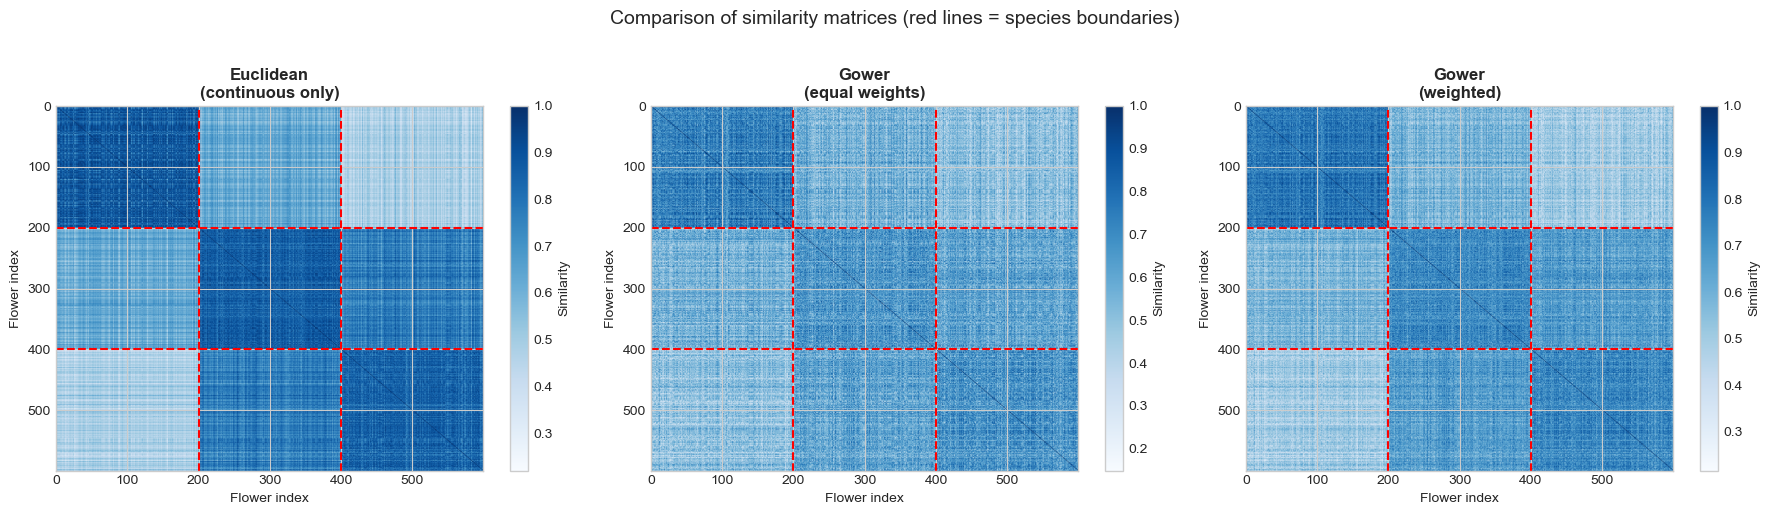


STATISTICS FOR SIMILARITY MATRICES

Euclidean:
  Mean: 0.700
  Std: 0.160
  Min: 0.220
  Max: 0.995

Gower (equal):
  Mean: 0.599
  Std: 0.129
  Min: 0.149
  Max: 0.995

Gower (weighted):
  Mean: 0.637
  Std: 0.125
  Min: 0.217
  Max: 0.992


In [6]:
# Visualize the three similarity matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

matrices = [
    (sim_euclidean, "Euclidean\n(continuous only)"),
    (sim_gower_equal, "Gower\n(equal weights)"),
    (sim_gower_weighted, "Gower\n(weighted)")
]

for ax, (matrix, title) in zip(axes, matrices):
    im = ax.imshow(matrix, cmap='Blues', aspect='auto')
    
    # Add species boundaries
    for boundary in [200, 400]:
        ax.axhline(y=boundary, color='red', linestyle='--', linewidth=1.5)
        ax.axvline(x=boundary, color='red', linestyle='--', linewidth=1.5)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Flower index')
    ax.set_ylabel('Flower index')
    plt.colorbar(im, ax=ax, label='Similarity')

plt.suptitle('Comparison of similarity matrices (red lines = species boundaries)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Compute statistics
print("\n" + "="*70)
print("STATISTICS FOR SIMILARITY MATRICES")
print("="*70)

for name, matrix in [("Euclidean", sim_euclidean), 
                      ("Gower (equal)", sim_gower_equal), 
                      ("Gower (weighted)", sim_gower_weighted)]:
    # Exclude diagonal
    upper_tri = matrix[np.triu_indices(len(matrix), k=1)]
    print(f"\n{name}:")
    print(f"  Mean: {upper_tri.mean():.3f}")
    print(f"  Std: {upper_tri.std():.3f}")
    print(f"  Min: {upper_tri.min():.3f}")
    print(f"  Max: {upper_tri.max():.3f}")


### ❓ Reflection Questions 2

Look at the three similarity matrices and answer:

1. **Which matrix shows the clearest separation between species?** Why do you think that is?

2. **What happens to the similarity values when we add categorical variables?** Do they become higher or lower on average?

3. **How does the weighting affect the result?** Compare "Gower (equal)" with "Gower (weighted)".

4. **Clinical relevance:** If you were to build a PSN for diabetes patients with both continuous (blood pressure, HbA1c) and categorical (medication, lifestyle) variables – how would you weight them?


---
## Part 3: Build and Compare Networks

Now we build networks from the three similarity matrices and compare the results.


In [7]:
def build_network_from_similarity(sim_matrix: np.ndarray, 
                                   df: pd.DataFrame,
                                   threshold: float = 0.0) -> nx.Graph:
    """
    Build a NetworkX network from a similarity matrix.
    
    Parameters:
    -----------
    sim_matrix : np.ndarray
        n x n similarity matrix
    df : pd.DataFrame
        DataFrame with node attributes (must have 'species' column)
    threshold : float
        Minimum similarity to include an edge (0 = all edges)
    
    Returns:
    --------
    nx.Graph
        Weighted, undirected graph
    """
    G = nx.Graph()
    n = len(df)
    
    # Add nodes with attributes
    for i in range(n):
        G.add_node(i, 
                   species=df.iloc[i]['species'],
                   habitat=df.iloc[i]['habitat'],
                   region=df.iloc[i]['region'])
    
    # Add edges
    for i in range(n):
        for j in range(i+1, n):
            if sim_matrix[i, j] >= threshold:
                G.add_edge(i, j, weight=sim_matrix[i, j])
    
    return G

# Build three networks (complete, threshold=0)
G_euclidean = build_network_from_similarity(sim_euclidean, df_extended)
G_gower_equal = build_network_from_similarity(sim_gower_equal, df_extended)
G_gower_weighted = build_network_from_similarity(sim_gower_weighted, df_extended)

print("Networks built:")
for name, G in [("Euclidean", G_euclidean), 
                ("Gower (equal)", G_gower_equal), 
                ("Gower (weighted)", G_gower_weighted)]:
    print(f"  {name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Networks built:
  Euclidean: 600 nodes, 179700 edges
  Gower (equal): 600 nodes, 179700 edges
  Gower (weighted): 600 nodes, 179700 edges


### Step 7: Community detection and comparison


In [8]:
import community.community_louvain as community_louvain
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def analyze_community_detection(G: nx.Graph, df: pd.DataFrame, name: str) -> dict:
    """
    Perform community detection and compare with actual species.
    """
    # Perform Louvain community detection
    communities = community_louvain.best_partition(G)
    
    # Get actual species labels
    true_labels = [df.iloc[i]['species'] for i in range(len(df))]
    label_encoder = LabelEncoder()
    true_numeric = label_encoder.fit_transform(true_labels)
    
    # Get predicted communities
    pred_labels = [communities[i] for i in range(len(df))]
    
    # Compute metrics
    n_communities = len(set(communities.values()))
    modularity = community_louvain.modularity(communities, G)
    ari = adjusted_rand_score(true_numeric, pred_labels)
    nmi = normalized_mutual_info_score(true_numeric, pred_labels)
    
    return {
        'name': name,
        'n_communities': n_communities,
        'modularity': modularity,
        'ari': ari,  # Adjusted Rand Index
        'nmi': nmi,  # Normalized Mutual Information
        'communities': communities
    }

# Analyze all three networks
results = []
for name, G in [("Euclidean", G_euclidean), 
                ("Gower (equal)", G_gower_equal), 
                ("Gower (weighted)", G_gower_weighted)]:
    result = analyze_community_detection(G, df_extended, name)
    results.append(result)

# Display results in table
print("="*70)
print("COMMUNITY DETECTION RESULTS")
print("="*70)
print(f"\n{'Method':<20} {'# Comm.':<10} {'Modularity':<12} {'ARI':<10} {'NMI':<10}")
print("-"*62)
for r in results:
    print(f"{r['name']:<20} {r['n_communities']:<10} {r['modularity']:<12.3f} {r['ari']:<10.3f} {r['nmi']:<10.3f}")

print("\n📖 Explanation:")
print("  • # Comm. = Number of communities found")
print("  • Modularity = Quality of community structure (higher = better)")
print("  • ARI = Adjusted Rand Index (1 = perfect match with species)")
print("  • NMI = Normalized Mutual Information (1 = perfect match with species)")


COMMUNITY DETECTION RESULTS

Method               # Comm.    Modularity   ARI        NMI       
--------------------------------------------------------------
Euclidean            2          0.080        0.561      0.699     
Gower (equal)        3          0.056        0.484      0.538     
Gower (weighted)     2          0.063        0.554      0.681     

📖 Explanation:
  • # Comm. = Number of communities found
  • Modularity = Quality of community structure (higher = better)
  • ARI = Adjusted Rand Index (1 = perfect match with species)
  • NMI = Normalized Mutual Information (1 = perfect match with species)


<details>
<summary>🔬 <b>Deep Dive: Evaluation Metrics for Cluster Analysis</b> (click to expand)</summary>

### Adjusted Rand Index (ARI)

ARI measures the similarity between two cluster partitions, adjusted for chance:

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

- **ARI = 1**: Perfect match
- **ARI = 0**: Random match
- **ARI < 0**: Worse than random

### Normalized Mutual Information (NMI)

NMI measures information-theoretic similarity between partitions:

$$NMI = \frac{2 \cdot I(U;V)}{H(U) + H(V)}$$

where:
- $I(U;V)$ = mutual information between clusters
- $H(U), H(V)$ = entropy for each partition

- **NMI = 1**: Perfect match
- **NMI = 0**: No mutual information

### Modularity

Modularity measures how well a network is divided into communities:

$$Q = \frac{1}{2m}\sum_{ij} [A_{ij} - \frac{k_i k_j}{2m}]\delta(c_i, c_j)$$

- **Q > 0.3**: Significant community structure
- **Q > 0.7**: Strong community structure

### Which metric to choose?

| Situation | Recommended metric |
|-----------|------------------|
| Compare with known groups | ARI, NMI |
| Assess network structure | Modularity |
| Imbalanced cluster sizes | NMI (more robust) |
| All have equal weight | ARI |

</details>


### Step 8: Visualize the networks

We use a threshold-based approach to reduce visual clutter (only showing edges with high similarity).


In [10]:
# Build threshold-based networks for visualization (threshold = 0.7)
threshold = 0.7

G_euc_thresh = build_network_from_similarity(sim_euclidean, df_extended, threshold)
G_gow_eq_thresh = build_network_from_similarity(sim_gower_equal, df_extended, threshold)
G_gow_wt_thresh = build_network_from_similarity(sim_gower_weighted, df_extended, threshold)

print(f"Networks with threshold {threshold}:")
for name, G in [("Euclidean", G_euc_thresh), 
                ("Gower (equal)", G_gow_eq_thresh), 
                ("Gower (weighted)", G_gow_wt_thresh)]:
    print(f"  {name}: {G.number_of_edges()} edges")


Networks with threshold 0.7:
  Euclidean: 96077 edges
  Gower (equal): 40136 edges
  Gower (weighted): 59241 edges


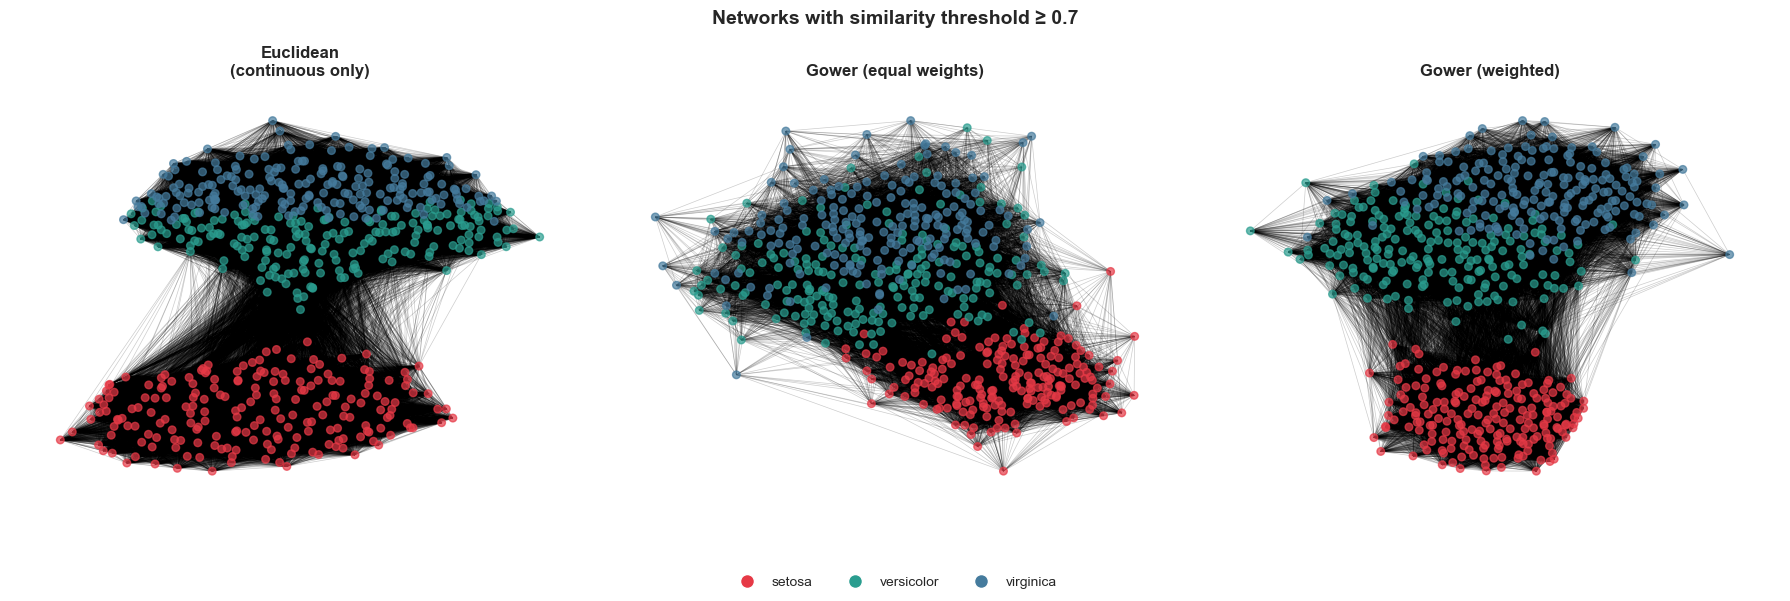

In [11]:
# Visualize the three networks
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Colors for species
color_dict = {
    'setosa': '#E63946',
    'versicolor': '#2A9D8F',
    'virginica': '#457B9D'
}

networks = [
    (G_euc_thresh, "Euclidean\n(continuous only)", results[0]['communities']),
    (G_gow_eq_thresh, "Gower (equal weights)", results[1]['communities']),
    (G_gow_wt_thresh, "Gower (weighted)", results[2]['communities'])
]

for ax, (G, title, communities) in zip(axes, networks):
    if G.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No edges\n(threshold too high)", 
                ha='center', va='center', fontsize=12)
        ax.set_title(title)
        ax.axis('off')
        continue
    
    # Colors based on species
    node_colors = [color_dict[G.nodes[node]['species']] for node in G.nodes()]
    
    # Layout
    pos = nx.spring_layout(G, k=2/np.sqrt(len(G.nodes())), seed=42, iterations=50)
    
    # Edge weights
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    
    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                           node_size=30, alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5, ax=ax)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color, label=species_name, markersize=10)
    for species_name, color in color_dict.items()
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10)

plt.suptitle(f'Networks with similarity threshold ≥ {threshold}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


### ❓ Reflection Questions 3

1. **How does the threshold choice affect the network structure?** Try changing `threshold` to 0.5 or 0.8 – what happens?

2. **Which method provides the best visual separation of species?** Does this match the ARI/NMI values?

3. **What does it mean that Gower (equal) has lower ARI than Euclidean?** Is this always undesirable?

4. **Practical consideration:** If the categorical variables (habitat, region) actually contain important clinical information – should we weight them higher or lower?


---
## Part 4: Analysis of Within-Species vs. Between-Species Similarity

Let's examine how the different methods affect the separation between species.


In [13]:
def analyze_within_between_similarity(sim_matrix: np.ndarray, 
                                       df: pd.DataFrame) -> dict:
    """
    Compute average similarity within and between species.
    """
    n = len(df)
    within = {s: [] for s in ['setosa', 'versicolor', 'virginica']}
    between = []
    
    for i in range(n):
        for j in range(i+1, n):
            s_i = df.iloc[i]['species']
            s_j = df.iloc[j]['species']
            sim = sim_matrix[i, j]
            
            if s_i == s_j:
                within[s_i].append(sim)
            else:
                between.append(sim)
    
    return {
        'within': {s: np.mean(v) for s, v in within.items()},
        'between': np.mean(between),
        'within_all': np.mean([np.mean(v) for v in within.values()]),
        'ratio': np.mean([np.mean(v) for v in within.values()]) / np.mean(between)
    }

# Analyze all three
print("="*70)
print("WITHIN-SPECIES VS. BETWEEN-SPECIES SIMILARITY")
print("="*70)

for name, sim_mat in [("Euclidean", sim_euclidean), 
                       ("Gower (equal)", sim_gower_equal), 
                       ("Gower (weighted)", sim_gower_weighted)]:
    analysis = analyze_within_between_similarity(sim_mat, df_extended)
    
    print(f"\n{name}:")
    print(f"  Within-species similarity:")
    for species, mean_sim in analysis['within'].items():
        print(f"    {species}: {mean_sim:.3f}")
    print(f"  Between-species similarity: {analysis['between']:.3f}")
    print(f"  Separation ratio: {analysis['ratio']:.2f}x")


WITHIN-SPECIES VS. BETWEEN-SPECIES SIMILARITY

Euclidean:
  Within-species similarity:
    setosa: 0.872
    versicolor: 0.857
    virginica: 0.842
  Between-species similarity: 0.622
  Separation ratio: 1.38x

Gower (equal):
  Within-species similarity:
    setosa: 0.735
    versicolor: 0.657
    virginica: 0.668
  Between-species similarity: 0.555
  Separation ratio: 1.24x

Gower (weighted):
  Within-species similarity:
    setosa: 0.789
    versicolor: 0.727
    virginica: 0.733
  Between-species similarity: 0.581
  Separation ratio: 1.29x


---
## 📚 Summary

### What Have We Learned?

| Concept | Description |
|---------|-------------|
| **Mixed data** | Data with different variable types requires specialized similarity measures |
| **Gower distance** | Universal measure that handles continuous, categorical, ordinal, and binary variables |
| **Weighting** | Weights can be adjusted based on domain knowledge – not all variables are equally important |
| **Evaluation** | ARI and NMI measure how well detected communities match known groups |
| **Trade-offs** | Adding variables can increase or decrease separation depending on their information content |

### Key Findings from This Experiment

1. **Euclidean (continuous only)** often provides better species separation because the four flower measurements are highly informative
2. **Gower with equal weights** can "dilute" the signal from the continuous variables
3. **Weighted Gower** is a good middle ground – includes extra information but prioritizes the most informative variables

### Transfer to Clinical Data

In clinical PSN applications:
- **Think carefully about weighting** – lab values may be more important than self-reported data
- **Validate against known groups** – use ARI/NMI if you have diagnosis groups
- **Experiment with threshold** – not all connections are equally relevant


---
## 💡 Exercises

### Exercise 1: Experiment with Weighting
Modify `custom_weights` to:
a) Give higher weight to habitat and region
b) Give zero weight to binary variables
c) Only use categorical variables

How does this affect ARI and NMI?

### Exercise 2: Threshold Analysis
Create a graph showing how ARI changes as a function of similarity threshold (0.3, 0.5, 0.7, 0.9).

### Exercise 3: Alternative Similarity Measure
Implement **Jaccard similarity** for the categorical variables and compare with Gower.

### Exercise 4: Clinical Design
Design a synthetic patient dataset with:
- Continuous: HbA1c, blood pressure, BMI
- Categorical: Medication type, lifestyle
- Ordinal: Pain level, functional level
- Binary: Smoker, diabetes

Generate data for 3 patient groups and build a PSN.


<details>
<summary>💡 <b>Hints for the Exercises</b> (click to expand)</summary>

### Hint for Exercise 1
```python
# a) Higher weight on habitat and region
weights_a = {
    'sepal_length': 1.0, 'sepal_width': 1.0, 
    'petal_length': 1.0, 'petal_width': 1.0,
    'habitat': 3.0, 'region': 3.0, 'leafshape': 1.0,  # ← Increased
    'health': 1.0, 'growth_stage_ord': 1.0,
    'blooming': 0.5, 'damaged': 0.5
}
```

### Hint for Exercise 2
```python
thresholds = [0.3, 0.5, 0.7, 0.9]
ari_scores = []

for thresh in thresholds:
    G_temp = build_network_from_similarity(sim_gower_weighted, df_extended, thresh)
    # ... community detection and ARI calculation
    ari_scores.append(ari)

plt.plot(thresholds, ari_scores)
```

### Hint for Exercise 3
Jaccard for categorical sets:
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

For categorical variables: count the number of variables that are the same, divide by total number.

</details>


<details>
<summary>✅ <b>Solution Proposal for Exercise 1: Experiment with Weighting</b> (click to expand)</summary>

### Task
Modify `custom_weights` to:
- a) Give higher weight to habitat and region
- b) Give zero weight to binary variables
- c) Only use categorical variables

### Solution

```python
# ============================================================================
# EXERCISE 1: Experiment with Weighting
# ============================================================================

# a) Higher weight on habitat and region
weights_a = {
    'sepal_length': 1.0, 'sepal_width': 1.0, 
    'petal_length': 1.0, 'petal_width': 1.0,
    'habitat': 3.0, 'region': 3.0, 'leafshape': 1.0,  # Habitat and region weighted 3x
    'health': 1.0, 'growth_stage_ord': 1.0,
    'blooming': 0.5, 'damaged': 0.5
}

# b) Zero weight for binary variables (effectively excludes them)
weights_b = {
    'sepal_length': 1.0, 'sepal_width': 1.0, 
    'petal_length': 1.0, 'petal_width': 1.0,
    'habitat': 1.0, 'region': 1.0, 'leafshape': 1.0,
    'health': 1.0, 'growth_stage_ord': 1.0,
    'blooming': 0.0, 'damaged': 0.0  # Zero weight
}

# c) Only categorical variables
weights_c = {
    'sepal_length': 0.0, 'sepal_width': 0.0,  # Zero weight
    'petal_length': 0.0, 'petal_width': 0.0,  # Zero weight
    'habitat': 1.0, 'region': 1.0, 'leafshape': 1.0,  # Only these
    'health': 0.0, 'growth_stage_ord': 0.0,
    'blooming': 0.0, 'damaged': 0.0
}

# Compute distance matrices for each weighting
results_weights = []

for name, weights in [("a) Habitat/region high", weights_a), 
                       ("b) Without binary", weights_b),
                       ("c) Only categorical", weights_c)]:
    
    dist_mat = compute_gower_distance(
        df_extended, continuous_cols, categorical_cols, 
        ordinal_cols, binary_cols, weights=weights
    )
    sim_mat = 1 - dist_mat
    
    # Build network and run community detection
    G_temp = build_network_from_similarity(sim_mat, df_extended, threshold=0.0)
    
    communities = community_louvain.best_partition(G_temp)
    true_labels = [df_extended.iloc[i]['species'] for i in range(len(df_extended))]
    true_numeric = LabelEncoder().fit_transform(true_labels)
    pred_labels = [communities[i] for i in range(len(df_extended))]
    
    ari = adjusted_rand_score(true_numeric, pred_labels)
    nmi = normalized_mutual_info_score(true_numeric, pred_labels)
    
    results_weights.append({
        'name': name,
        'ari': ari,
        'nmi': nmi,
        'n_communities': len(set(communities.values()))
    })

# Display results
print("="*70)
print("EFFECT OF DIFFERENT WEIGHTING")
print("="*70)
print(f"\n{'Weighting':<25} {'# Comm.':<10} {'ARI':<10} {'NMI':<10}")
print("-"*55)
for r in results_weights:
    print(f"{r['name']:<25} {r['n_communities']:<10} {r['ari']:<10.3f} {r['nmi']:<10.3f}")

# Compare with original
print(f"\n{'Original (weighted)':<25} {results[2]['n_communities']:<10} {results[2]['ari']:<10.3f} {results[2]['nmi']:<10.3f}")
```

### Expected Result and Interpretation

| Weighting | Expected effect |
|---------|------------------|
| **a) Habitat/region high** | ARI may increase if habitat/region correlates with species, or decrease if they add noise |
| **b) Without binary** | Small change – binary variables have low weight to begin with |
| **c) Only categorical** | Significantly lower ARI – categorical variables alone don't distinguish species as well |

**Conclusion:** The continuous variables (flower measurements) are most informative for species separation.

</details>


<details>
<summary>✅ <b>Solution Proposal for Exercise 2: Threshold Analysis</b> (click to expand)</summary>

### Task
Create a graph showing how ARI changes as a function of similarity threshold (0.3, 0.5, 0.7, 0.9).

### Solution

```python
# ============================================================================
# EXERCISE 2: Threshold Analysis
# ============================================================================

thresholds = np.arange(0.0, 0.95, 0.05)  # Finer resolution
ari_euclidean = []
ari_gower = []

for thresh in thresholds:
    # Test with Euclidean
    G_euc = build_network_from_similarity(sim_euclidean, df_extended, thresh)
    if G_euc.number_of_edges() > 0:
        comm_euc = community_louvain.best_partition(G_euc)
        true_numeric = LabelEncoder().fit_transform([df_extended.iloc[i]['species'] for i in range(len(df_extended))])
        pred_euc = [comm_euc[i] for i in range(len(df_extended))]
        ari_euclidean.append(adjusted_rand_score(true_numeric, pred_euc))
    else:
        ari_euclidean.append(np.nan)
    
    # Test with Gower (weighted)
    G_gow = build_network_from_similarity(sim_gower_weighted, df_extended, thresh)
    if G_gow.number_of_edges() > 0:
        comm_gow = community_louvain.best_partition(G_gow)
        pred_gow = [comm_gow[i] for i in range(len(df_extended))]
        ari_gower.append(adjusted_rand_score(true_numeric, pred_gow))
    else:
        ari_gower.append(np.nan)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ARI vs threshold
ax1 = axes[0]
ax1.plot(thresholds, ari_euclidean, 'b-o', label='Euclidean', markersize=4)
ax1.plot(thresholds, ari_gower, 'r-s', label='Gower (weighted)', markersize=4)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Similarity threshold', fontsize=12)
ax1.set_ylabel('Adjusted Rand Index (ARI)', fontsize=12)
ax1.set_title('ARI as a function of threshold', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 0.95])

# Plot 2: Number of edges vs threshold
n_edges_euc = []
n_edges_gow = []
for thresh in thresholds:
    G_euc = build_network_from_similarity(sim_euclidean, df_extended, thresh)
    G_gow = build_network_from_similarity(sim_gower_weighted, df_extended, thresh)
    n_edges_euc.append(G_euc.number_of_edges())
    n_edges_gow.append(G_gow.number_of_edges())

ax2 = axes[1]
ax2.semilogy(thresholds, n_edges_euc, 'b-o', label='Euclidean', markersize=4)
ax2.semilogy(thresholds, n_edges_gow, 'r-s', label='Gower (weighted)', markersize=4)
ax2.set_xlabel('Similarity threshold', fontsize=12)
ax2.set_ylabel('Number of edges (log scale)', fontsize=12)
ax2.set_title('Network density vs threshold', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal threshold
best_thresh_euc = thresholds[np.nanargmax(ari_euclidean)]
best_thresh_gow = thresholds[np.nanargmax(ari_gower)]
print(f"\nOptimal threshold (max ARI):")
print(f"  Euclidean: {best_thresh_euc:.2f} → ARI = {max(ari_euclidean):.3f}")
print(f"  Gower:    {best_thresh_gow:.2f} → ARI = {max(ari_gower):.3f}")
```

### Expected Result and Interpretation

**Typical pattern:**
- **Low threshold (0.0-0.3):** Network is nearly complete → community detection finds few/large groups → low ARI
- **Medium threshold (0.4-0.7):** Balance between signal and noise → optimal ARI
- **High threshold (0.8+):** Network fragments → many isolated components → ARI may fall or become unstable

**Important insight:** There is often a "sweet spot" for threshold that maximizes ARI – this is a form of hyperparameter tuning!

</details>


<details>
<summary>✅ <b>Solution Proposal for Exercise 3: Alternative Similarity Measure (Jaccard)</b> (click to expand)</summary>

### Task
Implement **Jaccard similarity** for the categorical variables and compare with Gower.

### Theory

The Jaccard index measures similarity between two sets:
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

For categorical variables we can interpret this as: "the proportion of variables where two observations have the same value".

### Solution

```python
# ============================================================================
# EXERCISE 3: Jaccard similarity for categorical variables
# ============================================================================

def compute_jaccard_categorical(df: pd.DataFrame, 
                                 categorical_cols: List[str]) -> np.ndarray:
    """
    Computes Jaccard similarity based on categorical variables.
    
    For categorical data: J(i,j) = (number of same values) / (number of variables)
    """
    n = len(df)
    p = len(categorical_cols)
    sim_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i, n):
            if i == j:
                sim_matrix[i, j] = 1.0
            else:
                # Count number of same values
                matches = sum(1 for col in categorical_cols 
                             if df.iloc[i][col] == df.iloc[j][col])
                # Jaccard: same / total
                jaccard = matches / p
                sim_matrix[i, j] = jaccard
                sim_matrix[j, i] = jaccard
    
    return sim_matrix

# Compute Jaccard for all categorical (including binary as categorical)
all_categorical = categorical_cols + binary_cols  # habitat, region, leafshape, blooming, damaged
sim_jaccard = compute_jaccard_categorical(df_extended, all_categorical)

print(f"Jaccard similarity matrix computed for {len(all_categorical)} categorical variables")
print(f"  Variables: {all_categorical}")

# Compare with Gower (categorical only)
weights_cat_only = {
    'sepal_length': 0.0, 'sepal_width': 0.0, 
    'petal_length': 0.0, 'petal_width': 0.0,
    'habitat': 1.0, 'region': 1.0, 'leafshape': 1.0,
    'health': 0.0, 'growth_stage_ord': 0.0,
    'blooming': 1.0, 'damaged': 1.0  # Include binary as categorical
}

dist_gower_cat = compute_gower_distance(
    df_extended, continuous_cols, categorical_cols, 
    ordinal_cols, binary_cols, weights=weights_cat_only
)
sim_gower_cat = 1 - dist_gower_cat

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Jaccard
im1 = axes[0].imshow(sim_jaccard, cmap='Blues', aspect='auto')
axes[0].set_title('Jaccard (categorical)', fontweight='bold')
for boundary in [200, 400]:
    axes[0].axhline(y=boundary, color='red', linestyle='--', linewidth=1)
    axes[0].axvline(x=boundary, color='red', linestyle='--', linewidth=1)
plt.colorbar(im1, ax=axes[0])

# Gower (categorical only)
im2 = axes[1].imshow(sim_gower_cat, cmap='Blues', aspect='auto')
axes[1].set_title('Gower (categorical only)', fontweight='bold')
for boundary in [200, 400]:
    axes[1].axhline(y=boundary, color='red', linestyle='--', linewidth=1)
    axes[1].axvline(x=boundary, color='red', linestyle='--', linewidth=1)
plt.colorbar(im2, ax=axes[1])

# Difference
diff = sim_jaccard - sim_gower_cat
im3 = axes[2].imshow(diff, cmap='RdBu', aspect='auto', vmin=-0.5, vmax=0.5)
axes[2].set_title('Difference (Jaccard - Gower)', fontweight='bold')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# Community detection comparison
print("\n" + "="*60)
print("COMMUNITY DETECTION: Jaccard vs Gower (categorical)")
print("="*60)

for name, sim_mat in [("Jaccard", sim_jaccard), ("Gower (cat.)", sim_gower_cat)]:
    G_temp = build_network_from_similarity(sim_mat, df_extended, threshold=0.0)
    communities = community_louvain.best_partition(G_temp)
    
    true_numeric = LabelEncoder().fit_transform([df_extended.iloc[i]['species'] for i in range(len(df_extended))])
    pred_labels = [communities[i] for i in range(len(df_extended))]
    
    ari = adjusted_rand_score(true_numeric, pred_labels)
    nmi = normalized_mutual_info_score(true_numeric, pred_labels)
    
    print(f"\n{name}:")
    print(f"  ARI: {ari:.3f}")
    print(f"  NMI: {nmi:.3f}")
    print(f"  Communities: {len(set(communities.values()))}")
```

### Expected Result and Interpretation

**Jaccard vs Gower for categorical data:**
- For pure categorical variables, Jaccard and Gower are **identical** (both count proportion of same values)
- The difference should be approximately zero
- Jaccard is simpler to compute, but Gower is more flexible (supports weighting and mixed data)

**When to choose Jaccard?**
- When you only have categorical/binary data
- When you need a simple, interpretable metric
- Jaccard is standard in many text analysis/bioinformatics applications

</details>


<details>
<summary>✅ <b>Solution Proposal for Exercise 4: Clinical Design</b> (click to expand)</summary>

### Task
Design a synthetic patient dataset with:
- Continuous: HbA1c, blood pressure, BMI
- Categorical: Medication type, lifestyle
- Ordinal: Pain level, functional level
- Binary: Smoker, diabetes

Generate data for 3 patient groups and build a PSN.

### Solution

```python
# ============================================================================
# EXERCISE 4: Clinical patient dataset
# ============================================================================

def generate_clinical_dataset(n_per_group: int = 100, random_state: int = 42) -> pd.DataFrame:
    """
    Generates a synthetic clinical dataset with 3 patient groups:
    - Group A: Healthy controls
    - Group B: Pre-diabetes / at-risk patients
    - Group C: Type 2 diabetes patients
    """
    np.random.seed(random_state)
    
    # Parameters for each group
    group_params = {
        'A_healthy': {
            'HbA1c': (5.2, 0.3),           # Normal
            'bp_systolic': (120, 10),       # Normal
            'BMI': (23, 3),                 # Normal
            'medication_probs': [0.9, 0.08, 0.02],  # none, metformin, insulin
            'lifestyle_probs': [0.6, 0.3, 0.1],     # active, moderate, sedentary
            'pain_mean': 1.5,               # Low pain
            'function_mean': 4.5,           # High function
            'smoker_prob': 0.1,
            'diabetes_prob': 0.0
        },
        'B_atrisk': {
            'HbA1c': (6.0, 0.4),           # Elevated
            'bp_systolic': (135, 12),       # Elevated
            'BMI': (28, 4),                 # Overweight
            'medication_probs': [0.5, 0.4, 0.1],
            'lifestyle_probs': [0.2, 0.5, 0.3],
            'pain_mean': 2.5,
            'function_mean': 3.5,
            'smoker_prob': 0.25,
            'diabetes_prob': 0.0           # Pre-diabetes, not diagnosed
        },
        'C_diabetes': {
            'HbA1c': (7.8, 0.8),           # High
            'bp_systolic': (145, 15),       # High
            'BMI': (32, 5),                 # Obese
            'medication_probs': [0.1, 0.5, 0.4],
            'lifestyle_probs': [0.1, 0.3, 0.6],
            'pain_mean': 3.5,
            'function_mean': 2.5,
            'smoker_prob': 0.2,
            'diabetes_prob': 1.0           # All have diabetes
        }
    }
    
    medications = ['none', 'metformin', 'insulin']
    lifestyles = ['active', 'moderate', 'sedentary']
    
    data = []
    for group_name, params in group_params.items():
        for i in range(n_per_group):
            row = {
                'patient_id': f"{group_name[:1]}_{i+1:03d}",
                'group': group_name.split('_')[1],
                
                # Continuous
                'HbA1c': np.random.normal(*params['HbA1c']),
                'bp_systolic': np.random.normal(*params['bp_systolic']),
                'BMI': np.random.normal(*params['BMI']),
                
                # Categorical
                'medication': np.random.choice(medications, p=params['medication_probs']),
                'lifestyle': np.random.choice(lifestyles, p=params['lifestyle_probs']),
                
                # Ordinal (1-5 scale)
                'pain_level': np.clip(np.random.normal(params['pain_mean'], 0.8), 1, 5).round().astype(int),
                'function_level': np.clip(np.random.normal(params['function_mean'], 0.8), 1, 5).round().astype(int),
                
                # Binary
                'smoker': np.random.random() < params['smoker_prob'],
                'diabetes': np.random.random() < params['diabetes_prob']
            }
            data.append(row)
    
    return pd.DataFrame(data)

# Generate dataset
df_clinical = generate_clinical_dataset(n_per_group=100)

print(f"Clinical dataset generated: {len(df_clinical)} patients")
print(f"\nGroup distribution:")
print(df_clinical['group'].value_counts())
print(f"\nVariables: {list(df_clinical.columns)}")

# Define column types
cont_cols_clin = ['HbA1c', 'bp_systolic', 'BMI']
cat_cols_clin = ['medication', 'lifestyle']
ord_cols_clin = ['pain_level', 'function_level']
bin_cols_clin = ['smoker', 'diabetes']

# Compute Gower distance
print("\nComputing Gower distance...")
dist_clinical = compute_gower_distance(
    df_clinical, cont_cols_clin, cat_cols_clin, ord_cols_clin, bin_cols_clin
)
sim_clinical = 1 - dist_clinical

# Build network and run community detection
G_clinical = build_network_from_similarity(sim_clinical, df_clinical, threshold=0.0)

# Add group attribute
for i, row in df_clinical.iterrows():
    G_clinical.nodes[i]['group'] = row['group']

communities_clin = community_louvain.best_partition(G_clinical)

# Evaluate
true_labels_clin = df_clinical['group'].values
true_numeric_clin = LabelEncoder().fit_transform(true_labels_clin)
pred_labels_clin = [communities_clin[i] for i in range(len(df_clinical))]

ari_clin = adjusted_rand_score(true_numeric_clin, pred_labels_clin)
nmi_clin = normalized_mutual_info_score(true_numeric_clin, pred_labels_clin)

print(f"\n{'='*60}")
print("COMMUNITY DETECTION ON CLINICAL DATA")
print(f"{'='*60}")
print(f"ARI: {ari_clin:.3f}")
print(f"NMI: {nmi_clin:.3f}")
print(f"Number of communities: {len(set(communities_clin.values()))}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Similarity matrix
ax1 = axes[0]
im = ax1.imshow(sim_clinical, cmap='Blues', aspect='auto')
for boundary in [100, 200]:
    ax1.axhline(y=boundary, color='red', linestyle='--', linewidth=1.5)
    ax1.axvline(x=boundary, color='red', linestyle='--', linewidth=1.5)
ax1.set_title('Clinical PSN: Similarity matrix\n(red lines = group boundaries)', fontweight='bold')
ax1.set_xlabel('Patient index')
ax1.set_ylabel('Patient index')
plt.colorbar(im, ax=ax1, label='Similarity')

# Network visualization
ax2 = axes[1]
color_map_clin = {'healthy': '#2ECC71', 'atrisk': '#F39C12', 'diabetes': '#E74C3C'}
node_colors_clin = [color_map_clin[df_clinical.iloc[i]['group']] for i in G_clinical.nodes()]

# Use higher threshold for visualization
G_clin_vis = build_network_from_similarity(sim_clinical, df_clinical, threshold=0.7)
if G_clin_vis.number_of_edges() > 0:
    pos_clin = nx.spring_layout(G_clin_vis, k=2/np.sqrt(len(G_clin_vis.nodes())), seed=42)
    nx.draw_networkx_nodes(G_clin_vis, pos_clin, node_color=node_colors_clin, 
                           node_size=40, alpha=0.8, ax=ax2)
    nx.draw_networkx_edges(G_clin_vis, pos_clin, alpha=0.2, width=0.5, ax=ax2)
ax2.set_title('Clinical PSN: Network visualization\n(threshold=0.7)', fontweight='bold')
ax2.axis('off')

# Legend
legend_elements_clin = [
    plt.Line2D([0], [0], marker='o', color='w', 
               markerfacecolor=color, label=group, markersize=10)
    for group, color in color_map_clin.items()
]
ax2.legend(handles=legend_elements_clin, loc='upper right')

plt.tight_layout()
plt.show()

# Show group statistics
print(f"\n{'='*60}")
print("GROUP STATISTICS")
print(f"{'='*60}")
for group in ['healthy', 'atrisk', 'diabetes']:
    subset = df_clinical[df_clinical['group'] == group]
    print(f"\n{group.upper()}:")
    print(f"  HbA1c: {subset['HbA1c'].mean():.2f} ± {subset['HbA1c'].std():.2f}")
    print(f"  Blood pressure: {subset['bp_systolic'].mean():.1f} ± {subset['bp_systolic'].std():.1f}")
    print(f"  BMI: {subset['BMI'].mean():.1f} ± {subset['BMI'].std():.1f}")
    print(f"  Smokers: {subset['smoker'].sum()} ({subset['smoker'].mean()*100:.0f}%)")
```

### Expected Result and Interpretation

**Typical findings:**
- **High ARI/NMI** (>0.7): Groups are well separated – the clinical variables discriminate effectively
- **3 communities**: Ideally the algorithm finds the three original groups
- **Similarity matrix**: Clear block structures along the diagonal show within-group similarity

**Clinical relevance:**
This example shows how PSN can be used to:
1. **Identify patient groups** based on clinical profiles
2. **Detect at-risk patients** who resemble diabetes patients
3. **Stratify patients** for personalized treatment

**Extensions:**
- Add more variables (cholesterol, creatinine, age)
- Experiment with weighting (e.g., higher weight on HbA1c)
- Test different threshold values for the network

</details>


---
## 📖 References

- **Gower distance**: Gower, J.C. (1971). ["A general coefficient of similarity and some of its properties"](https://www.jstor.org/stable/2528823). *Biometrics*, 27(4), 857-871.

- **Louvain algorithm**: Blondel, V.D., Guillaume, J.L., Lambiotte, R., & Lefebvre, E. (2008). ["Fast unfolding of communities in large networks"](https://arxiv.org/abs/0803.0476). *Journal of Statistical Mechanics: Theory and Experiment*, P10008.

- **Adjusted Rand Index**: Hubert, L. & Arabie, P. (1985). ["Comparing partitions"](https://link.springer.com/article/10.1007/BF01908075). *Journal of Classification*, 2(1), 193-218.

- **Patient Similarity Networks**: Pai, S. & Bader, G.D. (2018). ["Patient Similarity Networks for Precision Medicine"](https://doi.org/10.1016/j.jmb.2018.05.037). *Journal of Molecular Biology*, 430(18), 2924-2938.

- **Mixed data clustering**: Huang, Z. (1998). ["Extensions to the k-means algorithm for clustering large data sets with categorical values"](https://link.springer.com/article/10.1023/A:1009769707641). *Data Mining and Knowledge Discovery*, 2(3), 283-304.

- **IRIS dataset**: Fisher, R.A. (1936). ["The use of multiple measurements in taxonomic problems"](https://onlinelibrary.wiley.com/doi/10.1111/j.1469-1809.1936.tb02137.x). *Annals of Eugenics*, 7(2), 179-188.

- **NetworkX**: Hagberg, A.A., Schult, D.A. & Swart, P.J. (2008). ["Exploring network structure, dynamics, and function using NetworkX"](https://conference.scipy.org/proceedings/SciPy2008/paper_2/). *Proceedings of the 7th Python in Science Conference (SciPy2008)*, 11-15.
